<a href="https://colab.research.google.com/github/khushbukushwaha1182-ops/Air-Quality-Data-Analysis/blob/main/Air_Quality_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
from google.colab import files
uploaded = files.upload()

Saving air_quality_global.csv to air_quality_global.csv


In [3]:
#Load dataset
df = pd.read_csv('air_quality_global.csv')


In [5]:
df['city'].unique()

array(['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix',
       'Philadelphia', 'San Antonio', 'San Diego', 'Dallas', 'San Jose',
       'London', 'Paris', 'Berlin', 'Tokyo', 'Beijing', 'Mumbai', 'Delhi',
       'São Paulo', 'Mexico City', 'Lagos'], dtype=object)

In [9]:
df.head()

,city,country,latitude,longitude,year,month,pm25_ugm3,no2_ugm3,data_quality,measurement_method,data_source
0,New York,USA,40.7128,-74.006,1999,1,18.11,35.98,Moderate,Reference/Equivalent Method,EPA_AQS
1,New York,USA,40.7128,-74.006,1999,2,27.79,17.71,Good,Reference/Equivalent Method,EPA_AQS
2,New York,USA,40.7128,-74.006,1999,3,12.05,40.99,Moderate,Reference/Equivalent Method,EPA_AQS
3,New York,USA,40.7128,-74.006,1999,4,35.25,17.18,Poor,Reference/Equivalent Method,EPA_AQS
4,New York,USA,40.7128,-74.006,1999,5,38.39,25.07,Good,Reference/Equivalent Method,EPA_AQS


In [10]:
#Basic information
print("Exploratory Data Analysis (EDA) is an approach to analyzing data sets to summarize their main characteristics, often using visual methods. It helps to understand the data, identify patterns, detect anomalies, test hypotheses, and check assumptions with the help of statistical graphics and other data visualization methods. The steps below (df.info(), df.describe(), df.isnull().sum()) are all part of an initial EDA.")

df.info()
df.describe()
df.isnull().sum()

Exploratory Data Analysis (EDA) is an approach to analyzing data sets to summarize their main characteristics, often using visual methods. It helps to understand the data, identify patterns, detect anomalies, test hypotheses, and check assumptions with the help of statistical graphics and other data visualization methods. The steps below (df.info(), df.describe(), df.isnull().sum()) are all part of an initial EDA.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6480 entries, 0 to 6479
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   city                6480 non-null   object 
 1   country             6480 non-null   object 
 2   latitude            6480 non-null   float64
 3   longitude           6480 non-null   float64
 4   year                6480 non-null   int64  
 5   month               6480 non-null   int64  
 6   pm25_ugm3           6480 non-null   float64
 7   no2_ugm3            6480 non-

,0
city,0
country,0
latitude,0
longitude,0
year,0
month,0
pm25_ugm3,0
no2_ugm3,0
data_quality,0
measurement_method,0


In [ ]:
#Data cleaning
#Check duplicates

df.duplicated().sum()

#Remove duplicates if any

df.drop_duplicates(inplace=True)

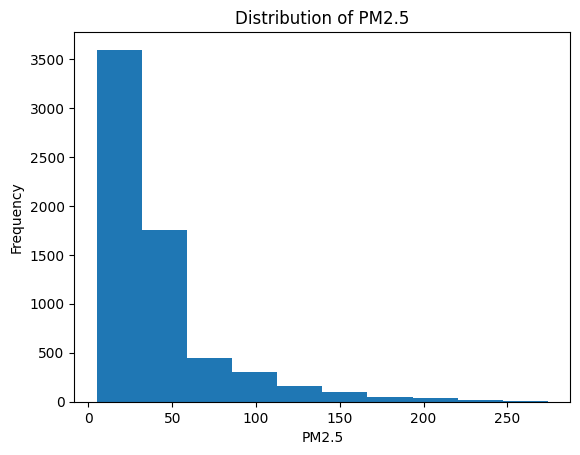

In [8]:
#Exploratory data analysis (EDA)
#Distribution of PM2.5

plt.hist(df['pm25_ugm3'])
plt.title('Distribution of PM2.5')
plt.xlabel('PM2.5')
plt.ylabel('Frequency')
plt.show()

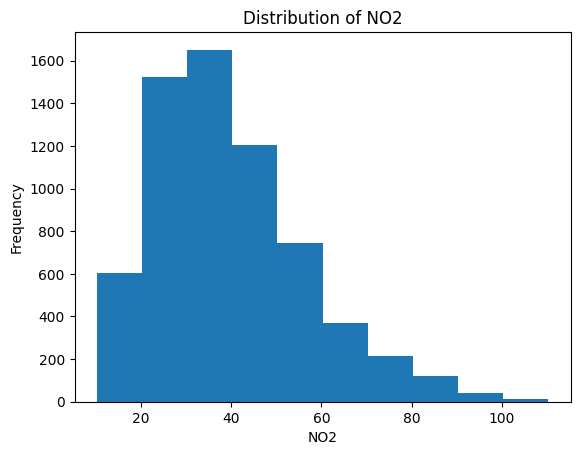

In [12]:
#Distribution of NO2

plt.hist(df['no2_ugm3'])
plt.title('Distribution of NO2')
plt.xlabel('NO2')
plt.ylabel('Frequency')
plt.show()

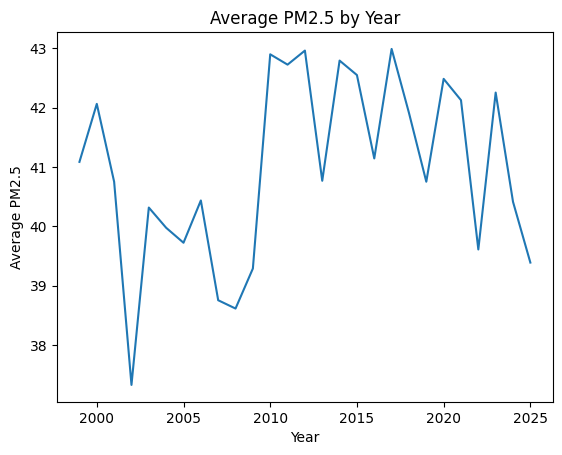

In [13]:
#Average PM2.5 by year

yearly_pm25 = df.groupby('year')['pm25_ugm3'].mean()
plt.plot(yearly_pm25.index, yearly_pm25.values)
plt.title('Average PM2.5 by Year')
plt.xlabel('Year')
plt.ylabel('Average PM2.5')
plt.show()

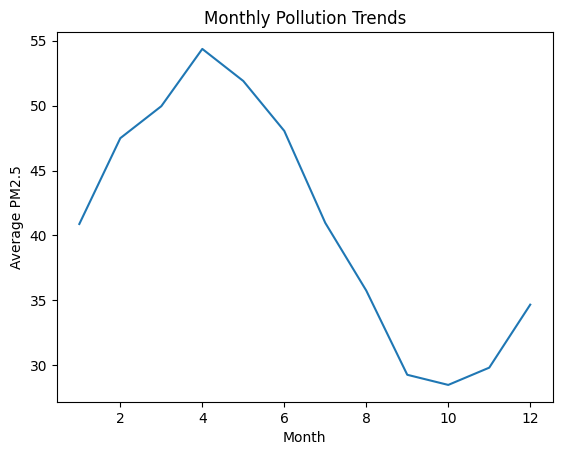

In [14]:
from matplotlib.typing import ColourType
#Monthly pollution trends

monthly_pm25 = df.groupby('month')['pm25_ugm3'].mean()
plt.plot(monthly_pm25.index, monthly_pm25.values)
plt.title('Monthly Pollution Trends')
plt.xlabel('Month')
plt.ylabel('Average PM2.5')
plt.show()


In [6]:
import plotly.express as px
import plotly.graph_objects as go

In [11]:
#City-wise analysis

city_pm25 = df.groupby('city')['pm25_ugm3'].mean().sort_values(ascending=False)
city_pm25.head(10)

,pm25_ugm3
city,
Delhi,132.012099
Mumbai,99.264969
Beijing,75.325123
Lagos,66.638086
Mexico City,53.446698
São Paulo,40.879691
Los Angeles,31.246728
Tokyo,29.550494
London,29.103148


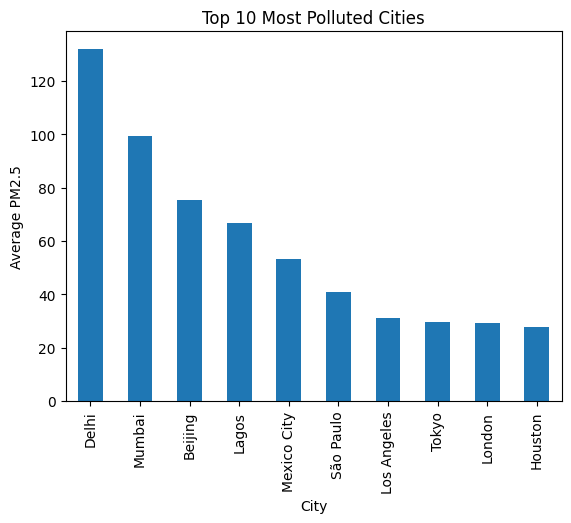

In [12]:
#Top 10 most polluted cities
top_pm25 = df.groupby('city')['pm25_ugm3'].mean().sort_values(ascending=False).head(10)
top_pm25.plot(kind='bar')
plt.title('Top 10 Most Polluted Cities')
plt.xlabel('City')
plt.ylabel('Average PM2.5')
plt.xticks(rotation=90)
plt.show()

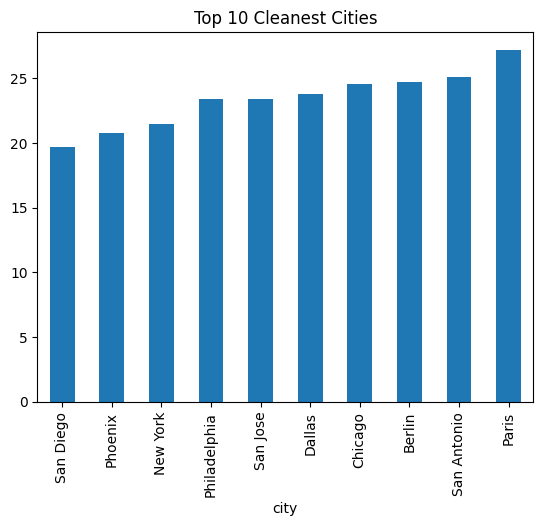

In [15]:
#Cleanest cities

cleanest = df.groupby('city')['pm25_ugm3'].mean().sort_values().head(10)
cleanest.plot(kind='bar')
plt.title('Top 10 Cleanest Cities')
plt.show()

